In [11]:
import pandas as pd
import nfl_data_py as nfl
from data.data_aggregation import import_pbp_data
from simulation.drive_selection import select_drive
from simulation.overtime_period import Overtime_Period
import matplotlib.pyplot as plt
from simulation.rules import *

In [2]:
DATA_DIR = r"C://Users//natel//PycharmProjects//NFL_Overtime_Model//data"
#df = pd.read_pickle(f'{DATA_DIR}//pbp_data.pkl')
drive_list = pd.read_csv(f'{DATA_DIR}//drive_list.csv')
ko_list = pd.read_csv(f"{DATA_DIR}//ko_list.csv")


In [3]:
agg_results = {}

for season in [2015, 2016,2023, 2024, 2025]:
    first_drive_results = []
    for _ in range(1000):
        OT = Overtime_Period('Kicking Team', 'Receiving Team', 'Kicking Team', season)  # was hardcoded to 2024
        OT.simulate()
        lines = OT.summary.split('\n')
        for line in lines:
            if ('scores a touchdown' in line or 'kicks a field goal' in line or
                'turns the ball over' in line or 'punts' in line):
                first_drive_results.append(line.strip())
                break
    agg_results[season] = pd.Series(first_drive_results).value_counts(normalize=True)

agg_df = pd.DataFrame(agg_results).fillna(0)
display(agg_df)

,2015,2016,2023,2024,2025
Kicking Team turns the ball over via DOWNS.,0.000000,0.000000,0.000,0.000,0.001001
Receiving Team kicks a field goal.,0.218876,0.227364,0.209,0.184,0.214214
Receiving Team punts.,0.481928,0.449698,0.429,0.418,0.407407
Receiving Team punts.Kicking Team returns it for a touchdown.,0.000000,0.000000,0.000,0.001,0.001001
Receiving Team scores a touchdown.,0.125502,0.162978,0.169,0.195,0.183183
Receiving Team turns the ball over via BLOCKED_FG.,0.001004,0.001006,0.000,0.001,0.002002
Receiving Team turns the ball over via DOWNS.,0.024096,0.020121,0.036,0.026,0.033033
Receiving Team turns the ball over via FUMBLE.,0.030120,0.016097,0.028,0.057,0.054054
Receiving Team turns the ball over via INTERCEPTION.,0.075301,0.086519,0.099,0.070,0.060060
Receiving Team turns the ball over via MISSED_FG.,0.043173,0.036217,0.030,0.048,0.044044


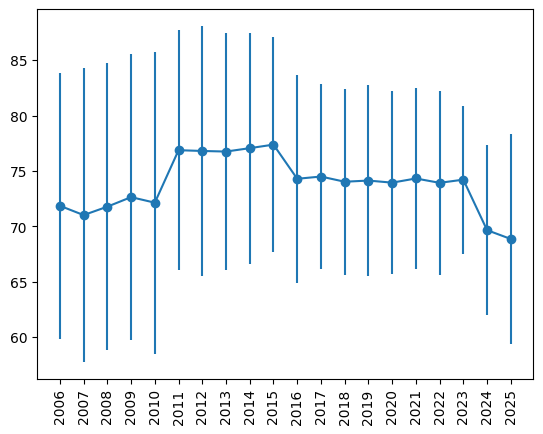

In [24]:
agg = ko_list.groupby('season')['starting_field_position'].agg(['mean', 'std'])
plt.errorbar(agg.index, agg['mean'], yerr=agg['std'], fmt='o-')
plt.xticks(agg.index.astype(int),rotation=90)

plt.show()

In [23]:
print(agg)

             mean        std
season                      
2006    71.863436  12.013555
2007    71.024797  13.284082
2008    71.784954  12.933921
2009    72.645669  12.884330
2010    72.143621  13.619172
2011    76.882309  10.855505
2012    76.813195  11.260752
2013    76.759696  10.719370
2014    77.066245  10.440596
2015    77.385128   9.736994
2016    74.301465   9.394394
2017    74.503988   8.391861
2018    74.034674   8.392334
2019    74.141527   8.601984
2020    73.951698   8.285930
2021    74.329514   8.189877
2022    73.936034   8.325465
2023    74.223404   6.676513
2024    69.663699   7.648266
2025    68.866736   9.447913


In [5]:
results = {}
for season in [2015, 2016, 2023, 2024, 2025]:
    fp = ko_list.groupby('season')['starting_field_position'].mean().loc[season]
    result, candidates = select_drive(drive_list, fp, overtime_length(season), 0, season)
    results[season] = candidates['drive_result'].value_counts(normalize = True)
display(pd.DataFrame(results).fillna(0))

,2015,2016,2023,2024,2025
drive_result,,,,,
DOWNS,0.02,0.03,0.03,0.03,0.02
FIELD_GOAL,0.17,0.21,0.21,0.16,0.19
FUMBLE,0.03,0.02,0.02,0.08,0.08
INTERCEPTION,0.07,0.10,0.10,0.07,0.06
MISSED_FG,0.03,0.03,0.03,0.05,0.07
PUNT,0.50,0.45,0.45,0.40,0.37
TOUCHDOWN,0.18,0.16,0.16,0.21,0.21


In [6]:
results[2025].append()

AttributeError: 'Series' object has no attribute 'append'

In [25]:
result, candidates = select_drive(drive_list, fp, 60, -3, season)
display(candidates)

,drive_id,start_yardline,start_time_left,start_posteam_score,start_defteam_score,start_score_diff,drive_result,time_elapsed,defteam_TD,posteam_score_change,defteam_score_change,last_play_yardline,last_ydstogo,next_drive_start_yardline
57294,2015_04_BAL_PIT_24,69,61.0,17.0,20.0,-3.0,FIELD_GOAL,54.0,False,3.0,0.0,24.0,2.0,80.0
80624,2018_20_NE_KC_21,69,32.0,28.0,31.0,-3.0,FIELD_GOAL,21.0,False,3.0,0.0,21.0,10.0,81.0
37528,2012_01_JAX_MIN_22,69,14.0,20.0,23.0,-3.0,FIELD_GOAL,10.0,False,3.0,0.0,37.0,4.0,75.0
10080,2007_12_MIA_PIT_19,69,13.0,0.0,3.0,-3.0,END_GAME,13.0,False,0.0,0.0,69.0,10.0,69.0
60728,2015_14_BUF_PHI_26,69,109.0,20.0,23.0,-3.0,INTERCEPTION,26.0,False,0.0,0.0,67.0,8.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35180,2011_12_TB_TEN_25,67,174.0,17.0,20.0,-3.0,INTERCEPTION,29.0,False,0.0,0.0,67.0,10.0,47.0
101472,2022_09_LV_JAX_18,69,183.0,20.0,24.0,-4.0,DOWNS,33.0,False,0.0,0.0,61.0,2.0,39.0
35920,2011_14_SF_ARI_27,68,171.0,19.0,21.0,-2.0,DOWNS,41.0,False,0.0,0.0,59.0,1.0,41.0
117778,2025_02_NYG_DAL_19,71,157.0,27.0,30.0,-3.0,TOUCHDOWN,105.0,False,7.0,0.0,15.0,0.0,63.0


In [ ]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)
print(drive_list.groupby('season')['drive_result']
      .apply(lambda x: (x == 'TOUCHDOWN').mean())
      .round(3))


In [ ]:
tied_drives = drive_list[drive_list['start_score_diff'] == 0]
print(tied_drives['drive_result'].value_counts(normalize=True))

In [ ]:
result = select_drive(drive_list, 25, 900, 0, 2011)
print(result)

In [ ]:
import pandas as pd

def get_ruleset(season, week):
    is_playoff = week > 18
    if season >= 2025:
        return 'post2025'
    elif season >= 2022 and is_playoff:
        return 'post2025'  # same rules as post2025
    elif season >= 2012:
        return '2012_2024'
    else:
        return 'pre2012'

def aggregate_overtime_games(pbp: pd.DataFrame) -> pd.DataFrame:
    ot_plays = pbp[pbp['game_half'] == 'Overtime'].copy()

    results = []

    for game_id, game in ot_plays.groupby('game_id'):
        game = game.sort_values('play_id')

        first_play = game.iloc[0]
        season = first_play['season']
        week = first_play['week']
        receiving_team = first_play['posteam']

        home = first_play['home_team']
        away = first_play['away_team']
        kicking_team = away if receiving_team == home else home

        last_play = game.iloc[-1]
        home_score = last_play['total_home_score']
        away_score = last_play['total_away_score']

        if home_score > away_score:
            winner = home
        elif away_score > home_score:
            winner = away
        else:
            winner = 'TIE'

        results.append({
            'game_id': game_id,
            'season': season,
            'week': week,
            'ruleset': get_ruleset(season, week),
            'kicking_team': kicking_team,
            'receiving_team': receiving_team,
            'winner': winner,
            'kicking_team_won': winner == kicking_team,
            'receiving_team_won': winner == receiving_team,
            'tie': winner == 'TIE',
        })

    return pd.DataFrame(results).sort_values(['season', 'week']).reset_index(drop=True)

In [39]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)


In [70]:
pcts = (
  drive_list.groupby(['season','start_yardline'])['drive_result']
  .value_counts(normalize=True)
  .unstack(fill_value=0)
)

pcts['SCORING'] = pcts['TOUCHDOWN']+pcts['FIELD_GOAL']
pcts.to_csv('scoring_pct.csv')

In [64]:
pcts.loc[int(agg.loc[2023, 'mean']), 'SCORING']

starting_pct = {}
for year in range(2010,2026):
    starting_pct[year] = pcts.loc[int(agg.loc[year, 'mean']), 'SCORING']
pd.DataFrame([starting_pct]).T


,0
2010,0.328825
2011,0.278130
2012,0.278130
2013,0.278130
2014,0.302289
2015,0.302289
2016,0.322747
2017,0.322747
2018,0.322747
2019,0.322747


ValueError: If using all scalar values, you must pass an index

In [ ]:
st

In [26]:
drive_list.groupby('start_yardline')['drive_result'].value_counts(normalize = True)

start_yardline  drive_result  
1               TOUCHDOWN         0.794521
                FIELD_GOAL        0.109589
                DOWNS             0.027397
                END_GAME          0.027397
                FUMBLE            0.013699
                                    ...   
99              DOWNS             0.021097
                MISSED_FG         0.014065
                BLOCKED_PUNT      0.002813
                FUMBLE,_SAFETY    0.002813
                BLOCKED_FG        0.001406
Name: proportion, Length: 1034, dtype: float64

In [ ]:
ot_df.groupby(['season']).agg(
    games=('game_id', 'count'),
    receiving_won=('receiving_team_won', 'sum'),
    kicking_won=('kicking_team_won', 'sum'),
    ties=('tie', 'sum'),
    receiving_pct=('receiving_team_won', 'mean'),
    kicking_pct=('kicking_team_won', 'mean'),
    tie_pct=('tie', 'mean'),
).round(3).T
